<a href="https://colab.research.google.com/github/yaj0212/Introductory-Machine-Learning/blob/main/assignments/assn4/assn4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introductory Machine Learning: Assignment 4

**Deadline:**

Assignment 4 is due Thursday, Apr 9 at 11:59pm. Late work will not be accepted as per the course policies (see the Syllabus and Course policies on [Canvas](https://canvas.yale.edu).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Acknowledge any use of an AI system such as ChatGPT or CoPilot.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on [Canvas](https://canvas.yale.edu).  You can also post questions or start discussions on [Ed Discussion](https://edstem.org/us/courses/91289/discussion). The problems are broken up into steps that should help you to make steady progress.

**Submission:**

Submit your assignment as a .pdf on Gradescope. You can access Gradescope through Canvas on the left-side of the class home page. The problems in each homework assignment are numbered. Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to find your complete solution to each problem.

To produce the .pdf, please do the following in order to preserve the cell structure of the notebook:  
1.  Go to "File" at the top-left of your Jupyter Notebook
2.  Under "Download as", select "HTML (.html)"
3.  After the .html has downloaded, open it and then select "File" and "Print" (note you will not actually be printing)
4.  From the print window, select the option to save as a .pdf

**Topics**
1. Language models
2. Word embeddings

### Problem 1: Gutenberg Books Language Models (15 points)

For this problem you will process books from the [Project Gutenberg](https://www.gutenberg.org/) site which is a public respository of large numbers of books that are in the public domain. You'll build *character-based* (as opposed to word-based) language models on one book, and predict the letters of the other book using the model.


In [1]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plots
%matplotlib inline

The following helper function `read_url` reads in the text at the given url, and then uses some
[regular expressions](https://www.w3schools.com/python/python_regex.asp) to process the book, removing
everything but the letters a-z, space and period.

In [2]:
from urllib.request import urlopen
import re

def read_url(url):
    return re.sub(r'\s+', ' ', urlopen(url).read().decode())

def process_text(text):
    text = re.sub(r'[^a-z .]', '', text.lower())
    return re.sub(r'[\[\]\_]', '', text)

<img src="https://www.gutenberg.org/cache/epub/76/pg76.cover.medium.jpg" width="210" align="top">

The online book for "Adventures of Huckleberry Finn," by Mark Twain, is [here](https://www.gutenberg.org/ebooks/76).
From this web site you can see various metadata for the book as well as the [link the text itself](https://www.gutenberg.org/files/76/76-0.txt), which is [https://www.gutenberg.org/files/76/76-0.txt](https://www.gutenberg.org/files/76/76-0.txt)

The book for Mark Twain's "A Connecticut Yankee in King Arthur's Court" is [here](https://www.gutenberg.org/ebooks/86).
In the following cell we read in both of these books, and remove all characters except a-z, space, and period.

In [3]:
huck_finn_url = 'https://www.gutenberg.org/files/76/76-0.txt'
huck_finn_text_raw = read_url(huck_finn_url)
huck_finn_text = process_text(huck_finn_text_raw)

ct_yankee_url = 'https://www.gutenberg.org/files/86/86-0.txt'
ct_yankee_text_raw = read_url(ct_yankee_url)
ct_yankee_text = process_text(ct_yankee_text_raw)


In [4]:
print("\nSample of raw text:\n")
print(huck_finn_text_raw[10000:11000])

print("\nSample of processed text:\n")
print(huck_finn_text[10000:11000])


Sample of raw text:

 tuck down her head and grumble a little over the victuals, though there warn’t really anything the matter with them,—that is, nothing only everything was cooked by itself. In a barrel of odds and ends it is different; things get mixed up, and the juice kind of swaps around, and the things go better. After supper she got out her book and learned me about Moses and the Bulrushers, and I was in a sweat to find out all about him; but by-and-by she let it out that Moses had been dead a considerable long time; so then I didn’t care no more about him, because I don’t take no stock in dead people. Pretty soon I wanted to smoke, and asked the widow to let me. But she wouldn’t. She said it was a mean practice and wasn’t clean, and I must try to not do it any more. That is just the way with some people. They get down on a thing when they don’t know nothing about it. Here she was a-bothering about Moses, which was no kin to her, and no use to anybody, being gone, you see, ye

<img src="https://www.gutenberg.org/cache/epub/1342/pg1342.cover.medium.jpg" width="210" align="top">


The online book for "Pride and Prejudice", by Jane Austen, is [here](https://www.gutenberg.org/ebooks/1342).
And [here](https://www.gutenberg.org/ebooks/158) is the online book for Jane Austen's "Emma".  In the following cell we read in both of these books, and remove all characters except a-z, space, and period.



In [5]:
pride_and_prejudice_url = 'https://www.gutenberg.org/files/1342/1342-0.txt'
pride_and_prejudice_text_raw = read_url(pride_and_prejudice_url)
pride_and_prejudice_text = process_text(pride_and_prejudice_text_raw)


emma_url = 'https://www.gutenberg.org/files/158/158-0.txt'
emma_text_raw = read_url(emma_url)
emma_text = process_text(emma_text_raw)

In [6]:
print("\nSample of raw text:\n")
print(emma_text_raw[10000:11000])

print("\nSample of processed text:\n")
print(emma_text[10000:11000])


Sample of raw text:

 to a late dinner, after some days’ absence, and now walked up to Hartfield to say that all were well in Brunswick Square. It was a happy circumstance, and animated Mr. Woodhouse for some time. Mr. Knightley had a cheerful manner, which always did him good; and his many inquiries after “poor Isabella” and her children were answered most satisfactorily. When this was over, Mr. Woodhouse gratefully observed, “It is very kind of you, Mr. Knightley, to come out at this late hour to call upon us. I am afraid you must have had a shocking walk.” “Not at all, sir. It is a beautiful moonlight night; and so mild that I must draw back from your great fire.” “But you must have found it very damp and dirty. I wish you may not catch cold.” “Dirty, sir! Look at my shoes. Not a speck on them.” “Well! that is quite surprising, for we have had a vast deal of rain here. It rained dreadfully hard for half an hour while we were at breakfast. I wanted them to put off the wedding.” “By 

The following cell defines some helper code. You should just run this cell; do not change any of the code.

The first function, `ngrams`, takes some input text and a value of `n`. The function then
iterates over the string and counts the number of occurrences of each substring of `n` characters. This is done with the very handy `Counter` class.

We then define a class `language_model` that is a 4-gram character-based language model. The probability of the "next character" is computed using linear interpolation, as described in class.  A weight is assigned to unigrams, bigrams, trigrams, and four-grams (quadgrams?). The bigram probability that, for example, the letter `t` follows the letter `h` is the count of the bigram `ht` divided by the count of the unigram `h`. We add a little bit (1e-10) to the denominator to avoid dividing by zero.

We return the logarithm of the probability, because this will be convenient when computing perplexities.


In [7]:
def ngrams(text, n=2):
    return Counter([text[(i-n):i] for i in np.arange(n, len(text)+1)])

class language_model:

    def __init__(self, text):
        self.one = ngrams(text, 1)
        self.two = ngrams(text, 2)
        self.three = ngrams(text, 3)
        self.four = ngrams(text, 4)
        self.weight = [0.1, 0.2, 0.3, 0.4]

    def set_weights(self, weights):
        self.weight = weights / np.sum(weights)

    def log_probability(self, gram):
        numer = [self.one[gram[3:]], self.two[gram[2:]], self.three[gram[1:]], self.four[gram[0:]]]
        denom = [sum(self.one[g] for g in self.one), self.one[gram[2:3]], self.two[gram[1:3]], self.three[gram[0:3]]]
        prob = 0
        for i in np.arange(4):
            prob += self.weight[i] * numer[i] / (denom[i]+1e-10)
        return np.log(prob)



### Problem 1.1

Just to be sure we understand what a character-based language model is, let's write an expression
for the probability in an example. Suppose the language model assigns
weight $w_1 = 0.1$ to the unigram model, weight $w_2 = 0.2$ to the bigram model, weight $w_3 = 0.3$ to the trigram model, and weight $w_4 = .4$ to the four-gram model. Note that we must have $w_1+w_2+w_3+w_4 = 1$.

Write an expression for the probability $p(\mbox{z} \,|\, \mbox{qui})$ that the letter $\mbox{z}$ follows the three letters $\mbox{qui}$. Assume that the unigram, bigram, trigram, and four-gram components are given by ratios of
counts in the training data, as in the code above. For example, the bigram probability would be written as

$$ \frac{\mbox{count}(iz)}{\mbox{count}(i)}$$


**Answer:**

$p(z|qui) = w_1 \cdot p(z) + w_2 \cdot p(z | i) + w_3 \cdot p(z | ui) + w_4 \cdot p(z | qui)$
$p(z|qui) = 0.1 \cdot \frac{\text{count(z)}}{\text{count(all letters)}} + 0.2 \cdot \frac{\text{count(iz)}}{\text{count(i)}} + 0.3 \cdot \frac{\text{count(uiz)}}{\text{count(ui)}} + 0.4 \cdot \frac{\text{count(quiz)}}{\text{count(qu)}}
$

Now, the cell below constructs two language models, one on the text of Jane Austen's "Emma", the other on the text of Mark Twain's "Huckleberry Finn". You will need it for Problem 1.3 - 1.6 later.

In [11]:
emma_lm = language_model(emma_text)
huck_finn_lm = language_model(huck_finn_text)

### Problem 1.2

In this sub-problem, your job is to write a function that takes a language model `lm`, and a text string `text`, and computes the perplexity of the language model on the text.

Hints:
* Your function can ignore the first three characters of the text. Thus, you can begin predicting the fourth character from the first three.
* Either extract the sequence of 4-character substrings, or make a call to `ngrams(text, n=4)` to get a set of 4-grams and their counts on the text.
* Compute the logarithm of probability of the text. If you compute the probability, you will get a very tiny number and numerical "underflow".
* Use the function `lm.log_probability` where `lm` is a instance of the class `language_model`. For example, `emma_lm.log_probability('emma')` will compute the logarithm of the probability that the character "a" follows the three characters "emm" using the language model computed on Jane Austen's "Emma".
* Once you have the logarithm of the probability of the entire text, you'll need to scale appropriately and then take the exponential, using `np.exp`.
* Work out the formula by "pencil and paper" before trying to write the function.


In [12]:
a = ngrams("the cat sat on the mat", n=4)
for i, j in a.items():
  print(i, j)

the  2
he c 1
e ca 1
 cat 1
cat  1
at s 1
t sa 1
 sat 1
sat  1
at o 1
t on 1
 on  1
on t 1
n th 1
 the 1
he m 1
e ma 1
 mat 1


In [13]:
def compute_perplexity(text, lm):
  # Your code here
  grams = ngrams(text, n=4)
  total_prob = 0
  for string, count in grams.items():
    prob = lm.log_probability(string)
    total_prob += prob * count
  perplexity = np.exp(-total_prob / (len(text) - 3))
  return perplexity


### Problem 1.3

To test your implementation of the perplexity function, evaluate the followign cell. This
computes the perplexity of the "Emma" language model on all four of the books: "Emma", "Pride and Prejudice", "Huckleberry Finn", and "Connecticut Yankee". For this problem, you will be graded on whether or not you get the correct four numbers for each of these perplexities.

Just run the following cell, which will evaluate the perplexities and print them out. No need to modify the code.

In [14]:
hf_perp = compute_perplexity(huck_finn_text, emma_lm)
ct_perp = compute_perplexity(ct_yankee_text, emma_lm)
pp_perp = compute_perplexity(pride_and_prejudice_text, emma_lm)
em_perp = compute_perplexity(emma_text, emma_lm)

print("Perplexity on Huckleberry Finn: %.2f" % hf_perp)
print("Perplexity on Connecticut Yankee: %.2f" % ct_perp)
print("Perplexity on Pride and Prejudice: %.2f" % pp_perp)
print("Perplexity on Emma: %.2f" % em_perp)

Perplexity on Huckleberry Finn: 6.45
Perplexity on Connecticut Yankee: 6.20
Perplexity on Pride and Prejudice: 5.52
Perplexity on Emma: 5.09


### Problem 1.4

Now, interpret your results above. Explain the meaning of perplexity for a character-based language model. Which book has the lowest perpexity? Why is this? Which book has the second smallest perplexity? Does this make sense? Explain.



**Answer:**

Emma has the lowest perplexity, and Pride and Prejudice has the second lowerst. Perplexity measures how surprised the model is, on average, when it sees each character in the text. Therefore, it's reasonable that Emma ranks on the lowest perplexity, since this language model is construct on the text of Jane Austen's Emma, indicating it has least supriseness. Pride and Prejudice ranks to be the second lowest is also reasonable, although it's a entirely different novel, it's also written by Jane Austen. The other two novels have high perplexity because they are written by Mark Twain, and may feature completely different styles of writing.

### Problem 1.5

Next, compute the perplexity of the "Huckleberry Finn" language model on each of the four books. Comment on your findings.

In [15]:
hf_perp = compute_perplexity(huck_finn_text, huck_finn_lm)# Your code here
ct_perp = compute_perplexity(ct_yankee_text, huck_finn_lm) # Your code here
pp_perp = compute_perplexity(pride_and_prejudice_text, huck_finn_lm)# Your code here
em_perp = compute_perplexity(emma_text, huck_finn_lm)# Your code here

print("Perplexity on Huckleberry Finn: %.2f" % hf_perp)
print("Perplexity on Connecticut Yankee: %.2f" % ct_perp)
print("Perplexity on Pride and Prejudice: %.2f" % pp_perp)
print("Perplexity on Emma: %.2f" % em_perp)

Perplexity on Huckleberry Finn: 5.08
Perplexity on Connecticut Yankee: 6.24
Perplexity on Pride and Prejudice: 6.61
Perplexity on Emma: 6.53


Comment on your findings.

**Answer:**
Now, Huckleberry Finn has the lowest perplexity and Connecticut Yankee has the second lowest. This is because the model we chose here is trained on Mark Twain's work. Naturally, the other two novels written by Jane Austen have higher perpleixty being assessed on Huckleberry Finn model.

### Problem 1.6
Finally, you will explore the optimal choice of weights assigned to your unigram, bigram, trigram, and four-gram models. Explore the weights provided in the question, fill in the codes, and comment on the finding.

 Recall that to set the weights on the language model `lm` you can use a function like `lm.set_weights([.25, .25, .25, .25])`.

1. Evaluate the perplexity of the "Pride and Prejudice" text using the following four configurations:

- Heavily Unigram: [0.7, 0.1, 0.1, 0.1]

- Uniform Split: [0.25, 0.25, 0.25, 0.25]

- Increasing Complexity: [0.1, 0.2, 0.3, 0.4]

- Extreme Four-gram: [0.01, 0, 0, 0.99]

Which weight set produced the lowest (best) perplexity? Do these weights make sense to you?

In [16]:
emma_lm.set_weights([0.7,0.1,0.1,0.1])
w1_perp = compute_perplexity(pride_and_prejudice_text, emma_lm)

emma_lm.set_weights([0.25,0.25,0.25,0.25])
w2_perp = compute_perplexity(pride_and_prejudice_text, emma_lm)

emma_lm.set_weights([0.1,0.2,0.3,0.4])
w3_perp = compute_perplexity(pride_and_prejudice_text, emma_lm)

emma_lm.set_weights([0.01,0,0,0.99])
w4_perp = compute_perplexity(pride_and_prejudice_text, emma_lm)

print("Perplexity using weights [0.7,0.1,0.1,0.1]: %.2f" % w1_perp)
print("Perplexity using weights [0.25,0.25,0.25,0.25]: %.2f" % w2_perp)
print("Perplexity using weights [0.1,0.2,0.3,0.4]: %.2f" % w3_perp)
print("Perplexity using weights [0.01,0,0,0.99]: %.2f" % w4_perp)

Perplexity using weights [0.7,0.1,0.1,0.1]: 9.73
Perplexity using weights [0.25,0.25,0.25,0.25]: 6.47
Perplexity using weights [0.1,0.2,0.3,0.4]: 5.52
Perplexity using weights [0.01,0,0,0.99]: 4.77


Comment your findings.

**Answer:**

Extreme Four-gram: [0.01, 0, 0, 0.99] sets the lowest perplexity. The perplexity of the "Pride and Prejudice" text decreases monotonically as more weight is placed on the four-gram component, which is also why the Extreme Four-gram works the best, it has the highest weight on $w_4$. Heavily Unigram is the worst one as its weights emphasized on different  compoenents.



2. Using the same weight configurations as above, find the weight set that produces the lowest perplexity of **Huckleberry Finn** using the **Emma** model. First, finish the code. Second, comment on the following: How do the weights you find compare to those you found above? Can you explain intuitively why they are different?

In [17]:
# Your code here
emma_lm.set_weights([0.7,0.1,0.1,0.1])
w1_huck = compute_perplexity(huck_finn_text, emma_lm)

emma_lm.set_weights([0.25,0.25,0.25,0.25])
w2_huck = compute_perplexity(huck_finn_text, emma_lm)

emma_lm.set_weights([0.1,0.2,0.3,0.4])
w3_huck = compute_perplexity(huck_finn_text, emma_lm)

emma_lm.set_weights([0.01,0,0,0.99])
w4_huck = compute_perplexity(huck_finn_text, emma_lm)

print("Perplexity using weights [0.7,0.1,0.1,0.1]: %.2f" % w1_huck)
print("Perplexity using weights [0.25,0.25,0.25,0.25]: %.2f" % w2_huck)
print("Perplexity using weights [0.1,0.2,0.3,0.4]: %.2f" % w3_huck)
print("Perplexity using weights [0.01,0,0,0.99]: %.2f" % w4_huck)

Perplexity using weights [0.7,0.1,0.1,0.1]: 10.28
Perplexity using weights [0.25,0.25,0.25,0.25]: 7.24
Perplexity using weights [0.1,0.2,0.3,0.4]: 6.45
Perplexity using weights [0.01,0,0,0.99]: 7.06


Comment your findings.

**Answer:**

The Increasing Complexity weight [0.1, 0.2, 0.3, 0.4] produce the lowest perplexity for Huckleberry Finn, and the Extreme Four-gram  [0.01, 0, 0, 0.99] actually got worse than it. Since Huckleberrry Finn is written by Mark Twain and using the model trained on Jane Austen's Emma, and it's normal that the best choice of weights results to be a different one.  The four-gram context becomes unreliable because many four-character sequences in Twain's prose probably never appeared in Austen's. Spreading weight more evenly across all orders lets the model fall back on shorter, more universal letter patterns that transfer better across different styles of English text.

### Problem 2: Word embedding experiments (15 points)

In this problem you will run experiments on word embeddings using two different algorithms or configurations: (1) word2vec embeddings trained on the "text8" Wikipedia corpus (2) GloVe embeddings pre-trained on a much larger corpus.

The text8 data are described here: http://mattmahoney.net/dc/textdata.html. The text8 file is a 100MB excerpt of Wikipedia. This small dataset is sufficient for our exploratory purposes, but note that it is far too small for any real application.
In the next few parts of this problem, you will construct word embeddings from the Wikipedia data.

`word2Vec` is a popular word embedding method. The following code will construct 100 dimensional embeddings on the text8 data.

Note: If you got the error message "unexpected keyword argument 'size'", it is because you are using a later version of gensim. You can solve the problem by using vector_size instead of size.

In [18]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.4 MB/s eta 0:00:00


In [19]:
# !pip install gensim # if using colab and get error message "No module named 'gensim'", uncomment this line
import gensim
from gensim.models import word2vec
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', \
                    level=logging.INFO)
sentences = word2vec.Text8Corpus('https://raw.githubusercontent.com/YData123/sds265-sp26/main/assignments/assn4/text8')

In [20]:
# this block takes time to run
model = word2vec.Word2Vec(sentences, vector_size=100, window=10, min_count=10)

The dictionary `model.wv`, keyed by words (as strings), has values which are the word embeddings (as numpy arrays).

We will also work with pre-trained GloVe embeddings. These embeddings were trained on a large corpus containing 6 billion tokens. You can load these embedding vectors using this code:

In [21]:
import gensim.downloader as gdl
glove = gdl.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


Here is a sample evaluation: puppy is to dog as what is to kitten?

In [22]:
glove.most_similar(positive = ['dog', 'kitten'], negative = ['puppy'])[0]

('cat', 0.6935379505157471)

###  Experiments

Conduct the following experiments with **both sets of embeddings**: the local word2vec embeddings, and the pre-trained GloVe embeddings. Based on the available memory on your computer, you may need to perform the experiments for each set of embeddings in a fresh Python session. Comment on the qualitative differences in the results for each of the embeddings.


#### 2.1 Find the closest words

For each of the following words, find the 5 closest words in the embedding space. Here, "closest" means in terms of cosine similarity. See the gensim documentation, and use the **most_similar** function.

          yale, physics, dessert, einstein, algebra, fish


In [23]:
words = ['yale','physics','dessert','einstein','algebra','fish']
w2v_results = [model.wv.most_similar(i, topn=5) for i in words]
glove_results = [glove.most_similar(i, topn = 5) for i in words]# Your code here

In [24]:
print(w2v_results)
print(glove_results)

[[('harvard', 0.8372842669487), ('rutgers', 0.7866324782371521), ('cornell', 0.7806681990623474), ('princeton', 0.77399080991745), ('graduate', 0.7461930513381958)], [('mechanics', 0.7818329930305481), ('quantum', 0.7492484450340271), ('cosmology', 0.7393573522567749), ('newtonian', 0.7380464673042297), ('electromagnetism', 0.73383629322052)], [('spicy', 0.8813009858131409), ('pork', 0.8763992786407471), ('soup', 0.8755375146865845), ('sauce', 0.8717413544654846), ('tomato', 0.8632363677024841)], [('heisenberg', 0.7990517020225525), ('schr', 0.7958458662033081), ('planck', 0.7936323285102844), ('fermi', 0.7931610345840454), ('maxwell', 0.7860680818557739)], [('algebraic', 0.8716169595718384), ('associative', 0.8254280090332031), ('algebras', 0.8247188329696655), ('banach', 0.8185186982154846), ('topology', 0.8181601166725159)], [('sheep', 0.8168260455131531), ('salmon', 0.8133640289306641), ('shrimp', 0.7950527667999268), ('cattle', 0.7925406098365784), ('fruit', 0.790414035320282)]]
[

Comment on your findings.

**Answer:**

Both models capture semantic similarity, but with some differences.

For 'yale,' both word2vec and glove return prestigious academic institutions as top neighbors.

For 'physics,' word2vec tends to find strings that have high relevance within the topic of physics, while glove tends to find strings that are academic disciplines at the same level of physics.

For 'dessert,' glove did a better job in capturing terms that are more relevant to dessert, whereas word2vec's neighbors have a confounded definition of dessert.

For 'einstein,' word2vec clusters a group of famous physicists while glove captures more terms of Einstein's ideas and field.

For 'algebra,' both word2vec and glove return its mathematical neighbors.

For 'fish,' word2vec places fish in a broad biological category cluster and finds other animal group nouns as neighbors, and glove finds specific seafood items people eat.

 Generally, the models sometimes capture fundamentally different aspects of the same word and it really depend on what contexts were most frequent during training.

#### 2.2 Complete analogies

A surprising consequence of some word embedding methods is that they can be used to resolve analogies, like

                   france :  paris ::  england :  ?
You can "solve" this analogy by computing the nearest embedding vector to $v$, where $v = v_{paris} − v_{france} + v_{england}$.

Now, solve the following analogies with **both sets** of word embeddings and report your results:

                   france :  paris ::  england :  ?
                   france :  paris ::  germany :  ?
                     queen :  woman ::  king :  ?                    


1. france :  paris ::  england :  ?

In [25]:
w2v_results = model.wv.most_similar(positive=['paris', 'england'], negative=['france'], topn=1)
glove_results = glove.most_similar(positive = ['paris', 'england'], negative = ['france'], topn = 1)# Your code here
print(w2v_results)
print(glove_results)

[('london', 0.6951937675476074)]
[('london', 0.812322735786438)]


2. france :  paris ::  germany :  ?

In [26]:
w2v_results = model.wv.most_similar(positive=['paris', 'germany'], negative=['france'], topn=1)# Your code here
glove_results = glove.most_similar(positive = ['paris', 'germany'], negative = ['france'], topn = 1)# Your code here
print(w2v_results)
print(glove_results)

[('berlin', 0.859337329864502)]
[('berlin', 0.8846380710601807)]


3. queen :  woman ::  king :  ?

In [27]:
w2v_results = model.wv.most_similar(positive=['woman', 'king'], negative=['queen'], topn=1)# Your code here
glove_results = glove.most_similar(positive = ['woman', 'king'], negative = ['queen'], topn = 1)# Your code here
print(w2v_results)
print(glove_results)

[('man', 0.6397379040718079)]
[('man', 0.790776789188385)]


Comment on your findings.

**Answer:**

france : paris :: england :

$v = v_{paris} − v_{france} + v_{england}$

$v - v_{england}= v_{paris} − v_{france} $

Expected answer should be London. Only glove gets it right. Word2vec returns Edinburgh, which is a plausible answer as it is also a major city of UK. But it missed the capital-city relationship (eg. Paris - France).

france : paris :: germany :

$v = v_{paris} − v_{france} + v_{germany}$

$v - v_{germany}= v_{paris} − v_{france} $

Expected answer should be Berlin. Both models succeessfully capture the capital-city relationship.

queen :  woman ::  king :

$v = v_{woman} − v_{queen} + v_{king}$

$v - v_{king}= v_{woman} − v_{queen}$

Expected answer should be man. Again only glove gets it correct. Word2vec returns jew which its relationship to 'king' is not similar as 'woman' is to 'queen.'

In these three specific testing cases, glove performs better than word2vec.

#### 2.3 Visualize embeddings

Use the t-SNE dimensionality reduction technique to visualize the embeddings in two dimensions. The sample code below will perform the t-SNE method on a subset of the vocabulary. You can start with this code and modify it to construct visualizations of the embeddings, or start with your own version of t-SNE.

The code provided shows the relative positions of the words conservative, liberal, elephant, and donkey based on GloVe embeddings. For your local embeddings, you may use similar code to visualize the embeddings.

Find an example that produces expected results and an example that produces surprising results for each of the two language models. Comment on the reason you think that you see surprising behavior here.


In [28]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# this functions computes and displays the 2-d t-SNE maps for a subset of the embedding vectors
# and displays them together with the points for a set of input words.

def display_tsne_neighborhood(model, input_word, nsample=1000, size1=2, size2=10, offset=5):

    arr = np.empty((0,100), dtype='f')
    word_label = input_word

    # add the vector for each of the closest words to the array
    for w in range(len(input_word)):
        if 'word2vec' in str(model.__class__):
            arr = np.append(arr, np.array([model.wv.get_vector(input_word[w])]), axis=0)
        else:
            arr = np.append(arr, np.array([model[input_word[w]]]), axis=0)

    if 'word2vec' in str(model.__class__):
        voc = [w for w in model.wv.index_to_key]
        wrds = np.random.choice(range(len(voc)), size=nsample, replace=False)
        for w in wrds:
            wrd_vector = model.wv.get_vector(voc[w])
            arr = np.append(arr, np.array([wrd_vector]), axis=0)
    else:
        voc = [w for w in model.key_to_index]
        wrds = np.random.choice(range(len(voc)), size=nsample, replace=False)
        for w in wrds:
            wrd_vector = model[voc[w]]
            arr = np.append(arr, np.array([wrd_vector]), axis=0)

    # find tsne coords for 2 dimensions
    tsne = TSNE(n_components=2, random_state=0)
    np.set_printoptions(suppress=True)
    Y = tsne.fit_transform(arr)

    x_coord = Y[:, 0]
    y_coord = Y[:, 1]
    # display scatter plot
    size=2
    plt.scatter(x_coord, y_coord, s=size1)
    plt.scatter(x_coord[0:len(input_word)], y_coord[0:len(input_word)],s=size2)

    # label the input words
    for w in range(len(input_word)):
        plt.annotate(input_word[w], xy=(x_coord[w],y_coord[w]), \
                     xytext=(w*offset,w*offset), textcoords='offset points')
    plt.show()

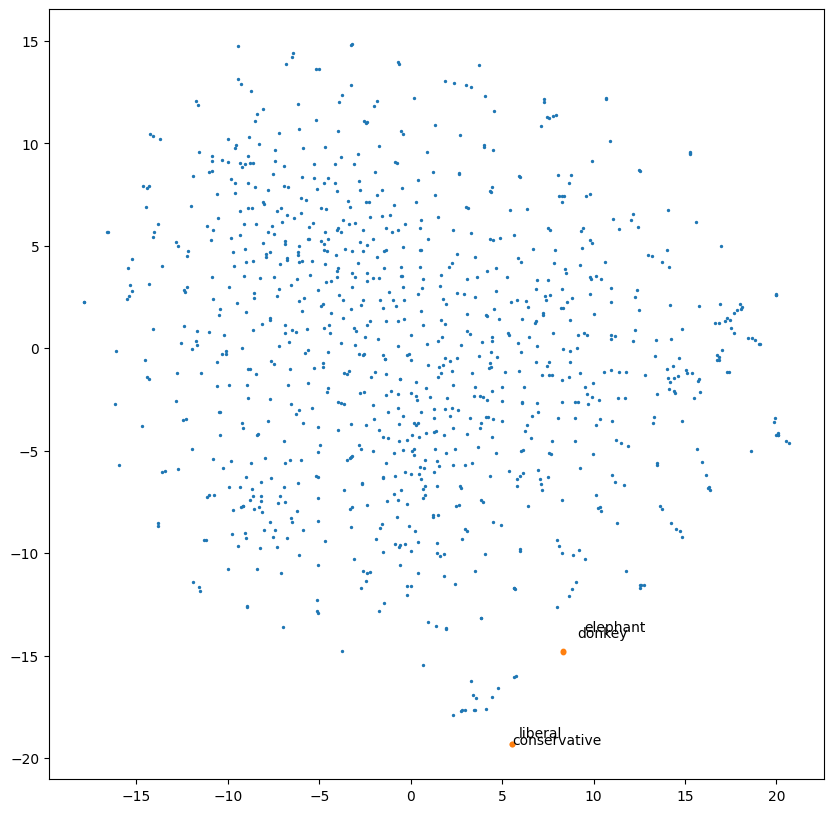

In [29]:
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, input_word = ['conservative', 'liberal', 'donkey', 'elephant'])

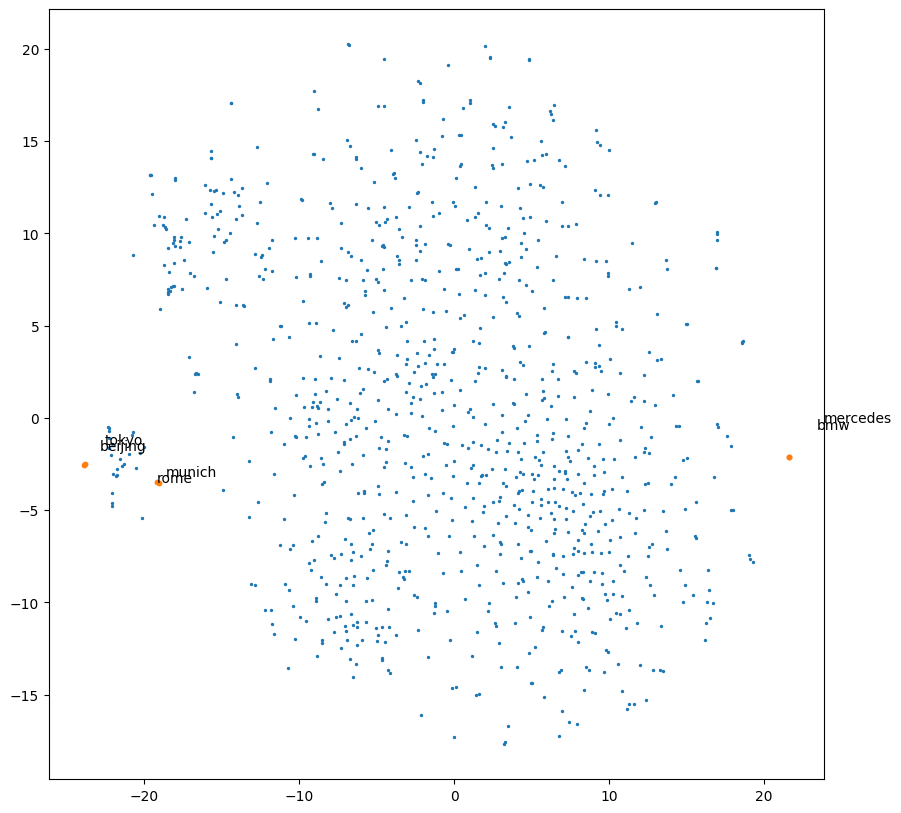

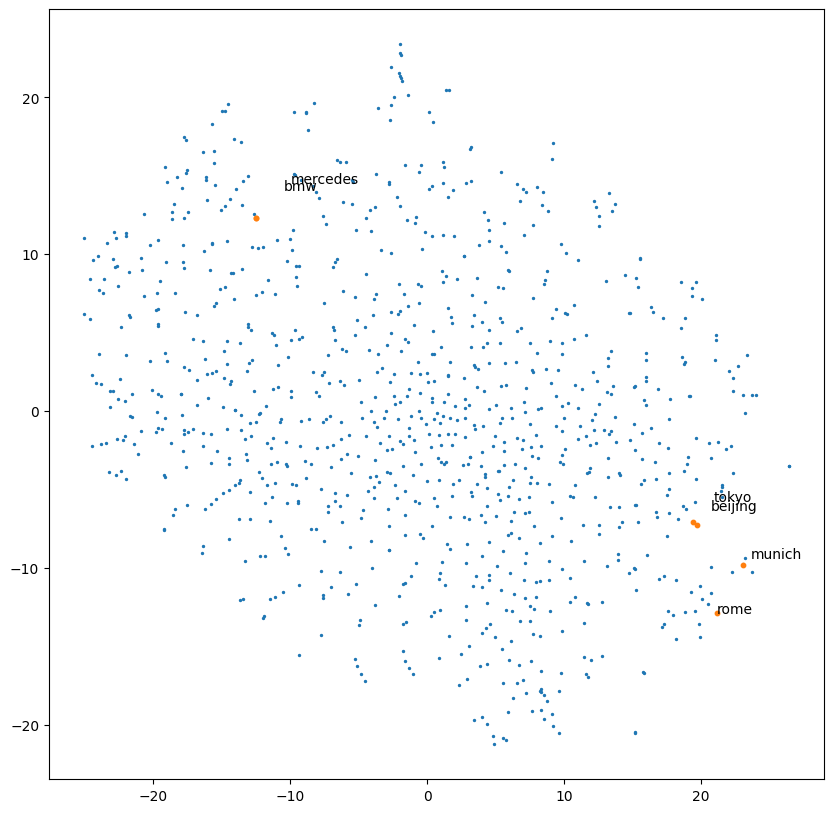

In [47]:
# Your code here for an expected example
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, input_word = ['rome', 'munich', 'beijing', 'tokyo', 'bmw', 'mercedes'])
plt.figure(figsize=(10,10))
display_tsne_neighborhood(model, input_word = ['rome', 'munich', 'beijing', 'tokyo', 'bmw', 'mercedes'])

**Answer:** Cities cluster together, and car brands cluster together in both models. This is an expected example as the embeddings have learned real-world categorical structure.

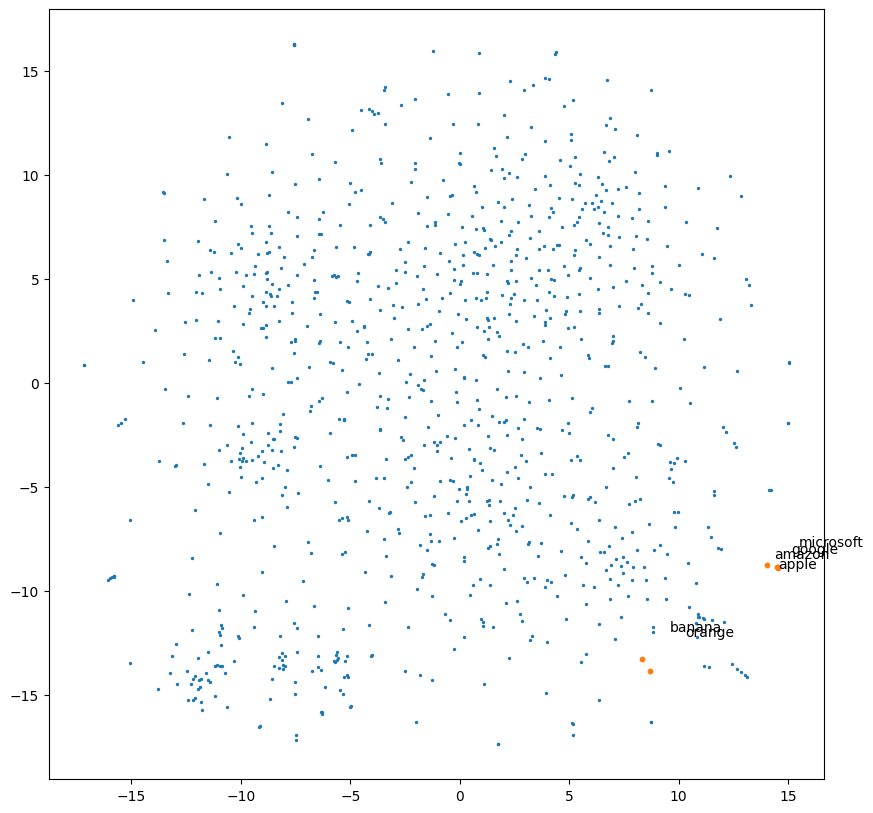

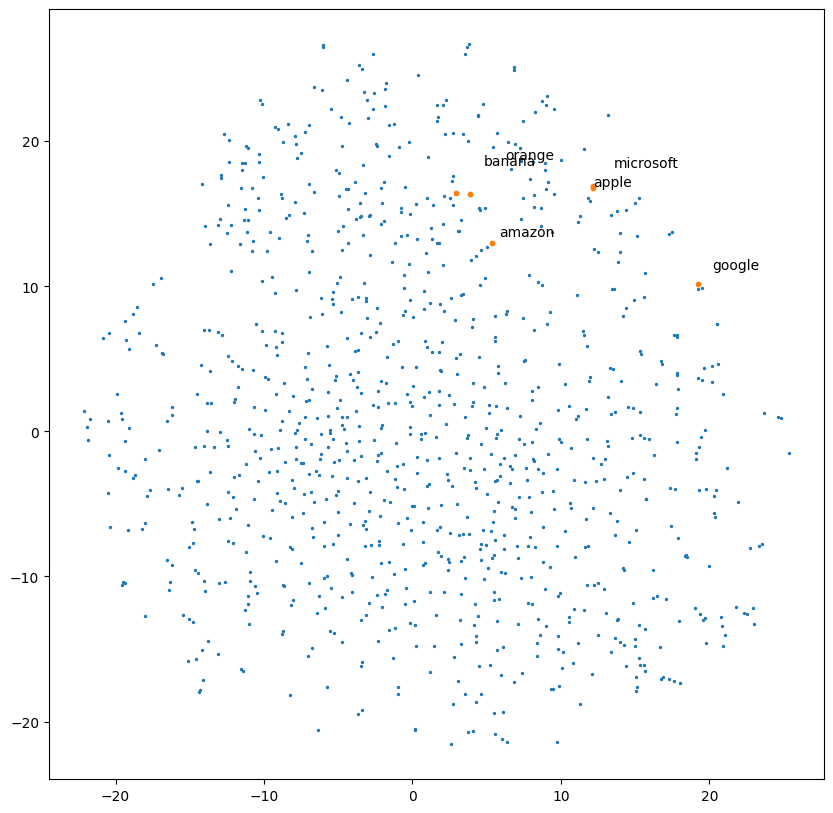

In [50]:
# Your code here for a surprising example
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, input_word = ['apple', 'amazon', 'google', 'microsoft', 'banana', 'orange'])
plt.figure(figsize=(10,10))
display_tsne_neighborhood(model, input_word = ['apple', 'amazon', 'google', 'microsoft', 'banana', 'orange'])

**Answer:**  This is a surprising example, since 'apple' and 'amazon' have mutliple meaning where 'apple' both a fruit and the name of a tech company, and 'amazon' both the name of a rainforest but also of a tech company. For flove embedding, apple clusters with amazon, google, and microsoft (the tech companies), while banana and orange cluster together separately. For word2vec, apple clusters with google and microsoft, but amazon sits far away from the tech cluster, and apple is noticeably closer to the fruit cluster (banana/orange).

### Problem  3: Experiments with Musician Embeddings (15 points)


In this problem, we will use a collection of playlists obtained from [last.fm](http://last.fm). We treat each playlist as a document, and each artist in the playlist as a word. By feeding this dataset to word2vec, we will be able to learn artist embeddings.

#### Artist Embeddings

The following experiments will be done with the playlist data file `playlists.txt`. Each line in this file is a playlist. The integers on each line are unique artist identifiers, indicating which artists were in each playlist. The artists are in `artists.txt`.

The code below constructs artist embeddings with word2vec. The artist names are mapped to id numbers in the playlists; the code maps them back to display the names.

In [51]:
import gensim
from gensim.models import word2vec
import logging

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [52]:
playlists = word2vec.LineSentence('https://raw.githubusercontent.com/YData123/sds265-sp26/main/assignments/assn4/playlists.txt')
music_model = word2vec.Word2Vec(playlists, vector_size=64, window=100, min_count=10)
# use size rather than vector_size in gensim version 3.8

In [53]:
music_model.wv['299']

array([ 0.60141253, -0.5348005 ,  0.04850189, -0.1524359 ,  0.91087115,
        0.5907992 , -0.49104556,  0.46706128, -0.20608157,  0.8155889 ,
       -0.31929258, -0.55049217, -0.95226234,  1.0699049 , -0.4141654 ,
        0.4759993 , -0.97180235, -0.37514618, -0.2507865 , -0.6739592 ,
        0.31196925, -0.16258653,  0.7173597 , -0.26368397,  0.05575046,
        1.0826561 ,  0.20264447, -0.47502604, -0.6985016 ,  0.06239539,
       -0.06959903, -0.45017996, -0.33338496, -0.26759875,  0.10017787,
       -0.17056456,  0.1029942 , -0.01284062, -0.6317562 , -0.3971444 ,
       -0.27410683,  0.15769525,  0.29021212,  0.40416768, -0.37357613,
       -0.0458681 ,  0.14196894, -0.8985062 ,  0.32918108,  1.1854461 ,
       -0.15374725, -0.42652458,  0.02043534,  1.3274156 ,  0.25288102,
        0.7253954 ,  0.25729606, -1.0770688 , -0.68911517,  0.5551596 ,
       -0.08051763, -1.3863952 ,  0.18388292,  0.45297343], dtype=float32)

In [54]:
from urllib.request import urlopen

artist = []
file = urlopen('https://raw.githubusercontent.com/YData123/sds265-sp26/main/assignments/assn4/artists.txt')
for line in file:
    art = line.decode("utf-8")
    artist.append(art.strip())

artist[0:10]

['Everette Harp',
 'Bishop Paul S. Morton & Aretha Franklin',
 'Frankie Ballard',
 'Herb Alpert',
 'Rod Stewart & Chaka Khan',
 'Scars On 45',
 'New Radicals',
 'Crosby, Stills & Nash',
 'Ledisi',
 'La Quinta Estacion']

In [56]:
id2name = {}
name2id = {}
for w in range(len(artist)):
    id2name["%s" % w] = artist[w]
    name2id[artist[w]] = "%s" % w

id2name[name2id['Elton John']]

'Elton John'

#### 3.1 Similar artists

Find the 5 closest artist embedding vectors to the artists "The Beatles", "Lady Gaga", and "Nirvana". Comment on the results.

In [57]:
# Don't change this function
def similar_artists(model, artist, n=5):
    id = name2id[artist]
    out = model.wv.most_similar(id, topn=n)

    print("artists similar to '%s'\n" % artist)
    for i in range(n) :
        name = id2name[out[i][0]]
        print("\t%s" % name)

similar_artists(music_model, 'Aerosmith')

artists similar to 'Aerosmith'

	Billy Idol
	The Black Crowes
	The Jimi Hendrix Experience
	Def Leppard
	Led Zeppelin


In [60]:
# Your code here
similar_artists(music_model, 'The Beatles')
similar_artists(music_model, 'Lady Gaga')
similar_artists(music_model, 'Nirvana')

artists similar to 'The Beatles'

	Steppenwolf
	Creedence Clearwater Revival
	The Electric Light Orchestra
	Grand Funk Railroad
	Stephen Stills
artists similar to 'Lady Gaga'

	Bruno Mars
	Katy Perry
	Black Eyed Peas
	J. Lo
	Ke$ha
artists similar to 'Nirvana'

	Bush
	Pearl Jam
	The Offspring
	Faith No More
	Audioslave


Comment on your findings.

**Answer:**

The Beatles is expected to surface other classic rock bands around 1970s. According to Wikipedia, Steppenwolf, Creedence Clearwater Revival, The Electric Light Orchestra, and Grand Funk Railroad are either American or British bands featuring 'classic rock' and 'oldies' playlists. Except Stephen Stills is a solo singer, but he's also famous for rock and country genre. Therefore, their embeddings are pulled close together.

Lady Gaga is a contemproray pop singer, and Bruno Mars, Katy Perry, Black Eyed Peas, J. Lo, Ke$ha are all mainstream pop acts from the late 2000s till now, who have dominated the same radio stations and playlists as Lady Gaga.

Nirvana is an American rock band in 1980s. According to Wikipedia, Bush,Pearl Jam, The Offspring, Faith No More, and Audioslave are all British/American rock groups formed between 1980s to 2000s. They all featured similar distorted guitars and vocal styles that Nirvana did. This cluster is musically precise in a way that The Beatls' result is not.

#### 3.2 Visualize embeddings

Use the t-SNE dimensionality reduction technique to visualize the artist embeddings. After running t-SNE on the artist embeddings, try visualizing "The Temptations" and "The Supremes" together.

In [61]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# this functions computes and displays the 2-d t-SNE maps for a subset of the embedding vectors
# and displays them together with the points for a set of input words.

def display_tsne_artists(model, artists, nsample=1000, size1=2, size2=10, offset=5):

    arr = np.empty((0,64), dtype='f')

    # add the vector for each of the closest words to the array
    for a in range(len(artists)):
        id = name2id[artists[a]]
        arr = np.append(arr, np.array([model.wv.get_vector(id)]), axis=0)

    voc = [w for w in model.wv.index_to_key]
    ids = np.random.choice(range(len(voc)), size=nsample, replace=False)
    for w in ids:
        wrd_vector = model.wv.get_vector(voc[w])
        arr = np.append(arr, np.array([wrd_vector]), axis=0)

    # find tsne coords for 2 dimensions
    tsne = TSNE(n_components=2, random_state=0)
    np.set_printoptions(suppress=True)
    Y = tsne.fit_transform(arr)

    x_coord = Y[:, 0]
    y_coord = Y[:, 1]
    # display scatter plot
    size=2
    plt.scatter(x_coord, y_coord, s=size1)
    plt.scatter(x_coord[0:len(artists)], y_coord[0:len(artists)],s=size2)

    # label the input words
    for w in range(len(artists)):
        plt.annotate(artists[w], xy=(x_coord[w],y_coord[w]), \
                     xytext=(w*offset,w*offset), textcoords='offset points')
    plt.show()

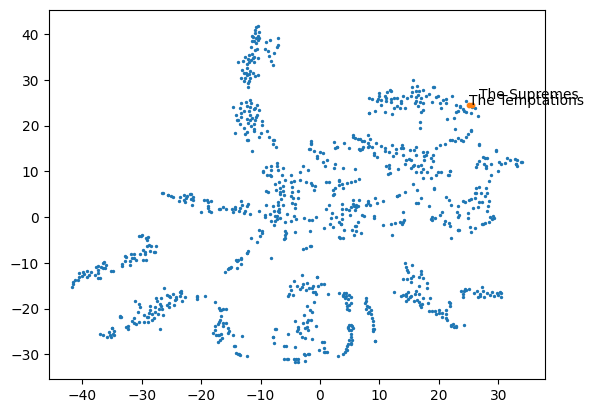

In [63]:
# Your code here
display_tsne_artists(music_model, ['The Temptations', 'The Supremes'])

Comment on your findings.

**Answer:**

The Temptations and The Supremes are both Motown soul groups from the 1960s who were labelmates at Motown Records and frequently appeared on the same playlists. In the t-SNE visualization, we expect them to be close in the embedding space.

This is an  expected result. Both artists are Motown acts from the same era (1960s), released on the same label (Motown Records), targeted the same audience, and frequently appeared together on playlists of that period. The model learned their similarity from co-occurrence in listening data and the t-SNE visualization confirms that the embeddings captured this real-world relationship correctly.

Pick another example that you think is interesting and comment on your findings.

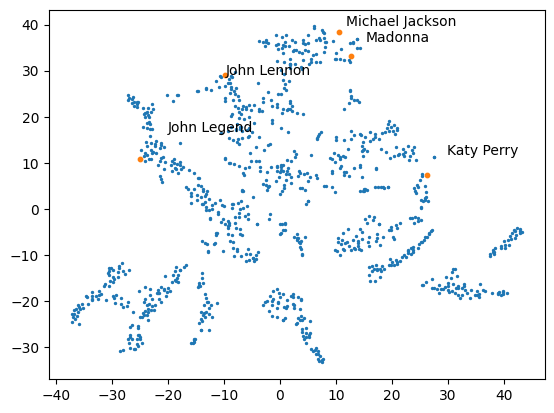

In [84]:
# Your code and comment here
display_tsne_artists(music_model, ['John Lennon', 'Michael Jackson', 'Madonna', 'Katy Perry', 'John Legend'])

**Answer:** I chose a list of artists to be John Lennon, Michael Jackson, Madonna, Katy Perry, and John Legend. The five artists are spread across the plot rather than forming one tight cluster. Michael Jackson and Madonna sit very close together in the upper-center region as they both  are 1980s megastars. John Lennon sits nearby but slightly separated from them, as He belongs to an earlier era but shares the "rock icon" context. John Legend is placed far to the left, the model correctly separates the similar name to John Lennon and classifies based on musical behavior. Katy Perry sits far to the right, as she belongs to a later (2010-20s) mainstream pop neighborhood that is somewhat different from classic rock cluster and the R&B cluster.


### Problem 4 Exploring MLP Architecture and Overfitting using Tensorflow Playground (15 points)
In this problem, you will use [TensorFlow Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.97904&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) to build intuition for how Multi-Layer Perceptrons (MLPs) work. Specifically, you will investigate how model complexity (layers, nodes, features) and training parameters affect a model's ability to generalize, and also demonstrate the concept of "overfitting."

#### 4.1 Generate two datasets and models
Step 1: Generate two datasets

First, you will design **two distinct datasets** (Dataset 1 and Dataset 2) using the "Data" column on the far left of the playground.

For each dataset, report the following design parameters:
* Starting Template: Choose one of the four patterns (Circles, Exclusive OR/Grid, Clusters, or Spirals).
* Ratio of Training to Test Data: (e.g., 50%)
* Noise: (e.g., 10-20% is usually good for forcing a model to overfit)
* Batch Size: (e.g., 10)

Step 2: Model Design and Training

You will design and train a total of four distinct models. You may adjust the input features ($X_1$, $X_2$, $X_1^2$, etc.), the number of hidden layers, the number of neurons per layer, the learning rate, and the regularization (L1/L2 or none), etc.

For Dataset 1:

* Model A (The Overfitter): Train this model on Dataset 1 with a hyperparameter setting where the model significantly overfits the data (e.g., low training loss but high testing loss).
* Model B (The Good Fit): Train this model on Dataset 1 using a different hyperparameter setting that captures the true underlying pattern of the same dataset without memorizing the noise. The Test Loss and Training Loss should be relatively close and low.

For Dataset 2:

* Model C (The Overfitter): Train this model on Dataset 2, again choosing hyperparameters where the model significantly overfits the data.
* Model D (The Good Fit): Train this model on Dataset 2 using hyperparameters that allow it to generalize well.

Allow each of your four models to train until the loss curves stabilize. **Take a screenshot of all four models and write down the parameters.** Ensure your screenshots capture the Data parameters, the Network Architecture, the final Output graph (decision boundary), and the "Test loss" vs "Training loss" metrics at the top right.

Screenshot for Model A


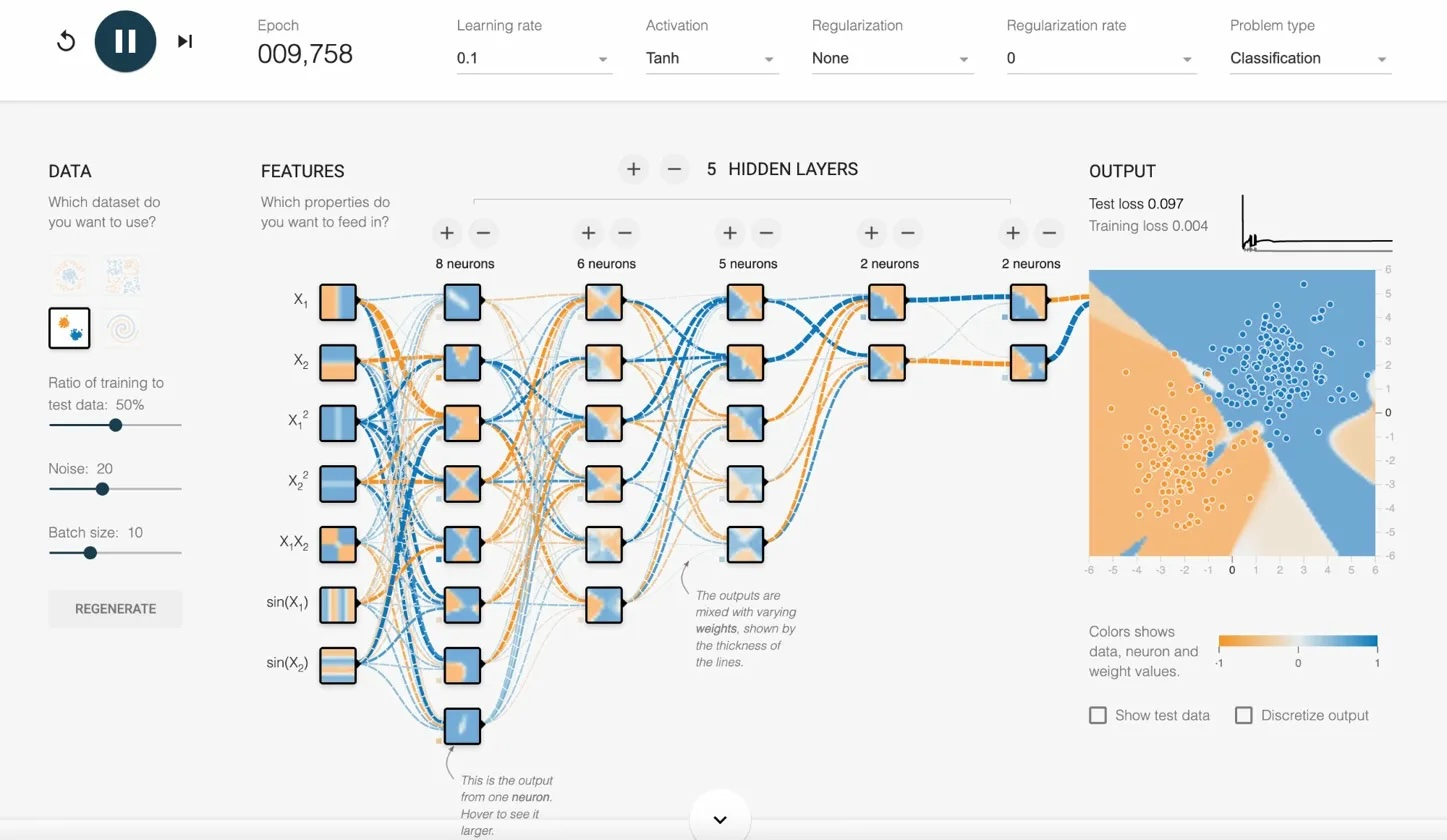

Screenshot for Model B

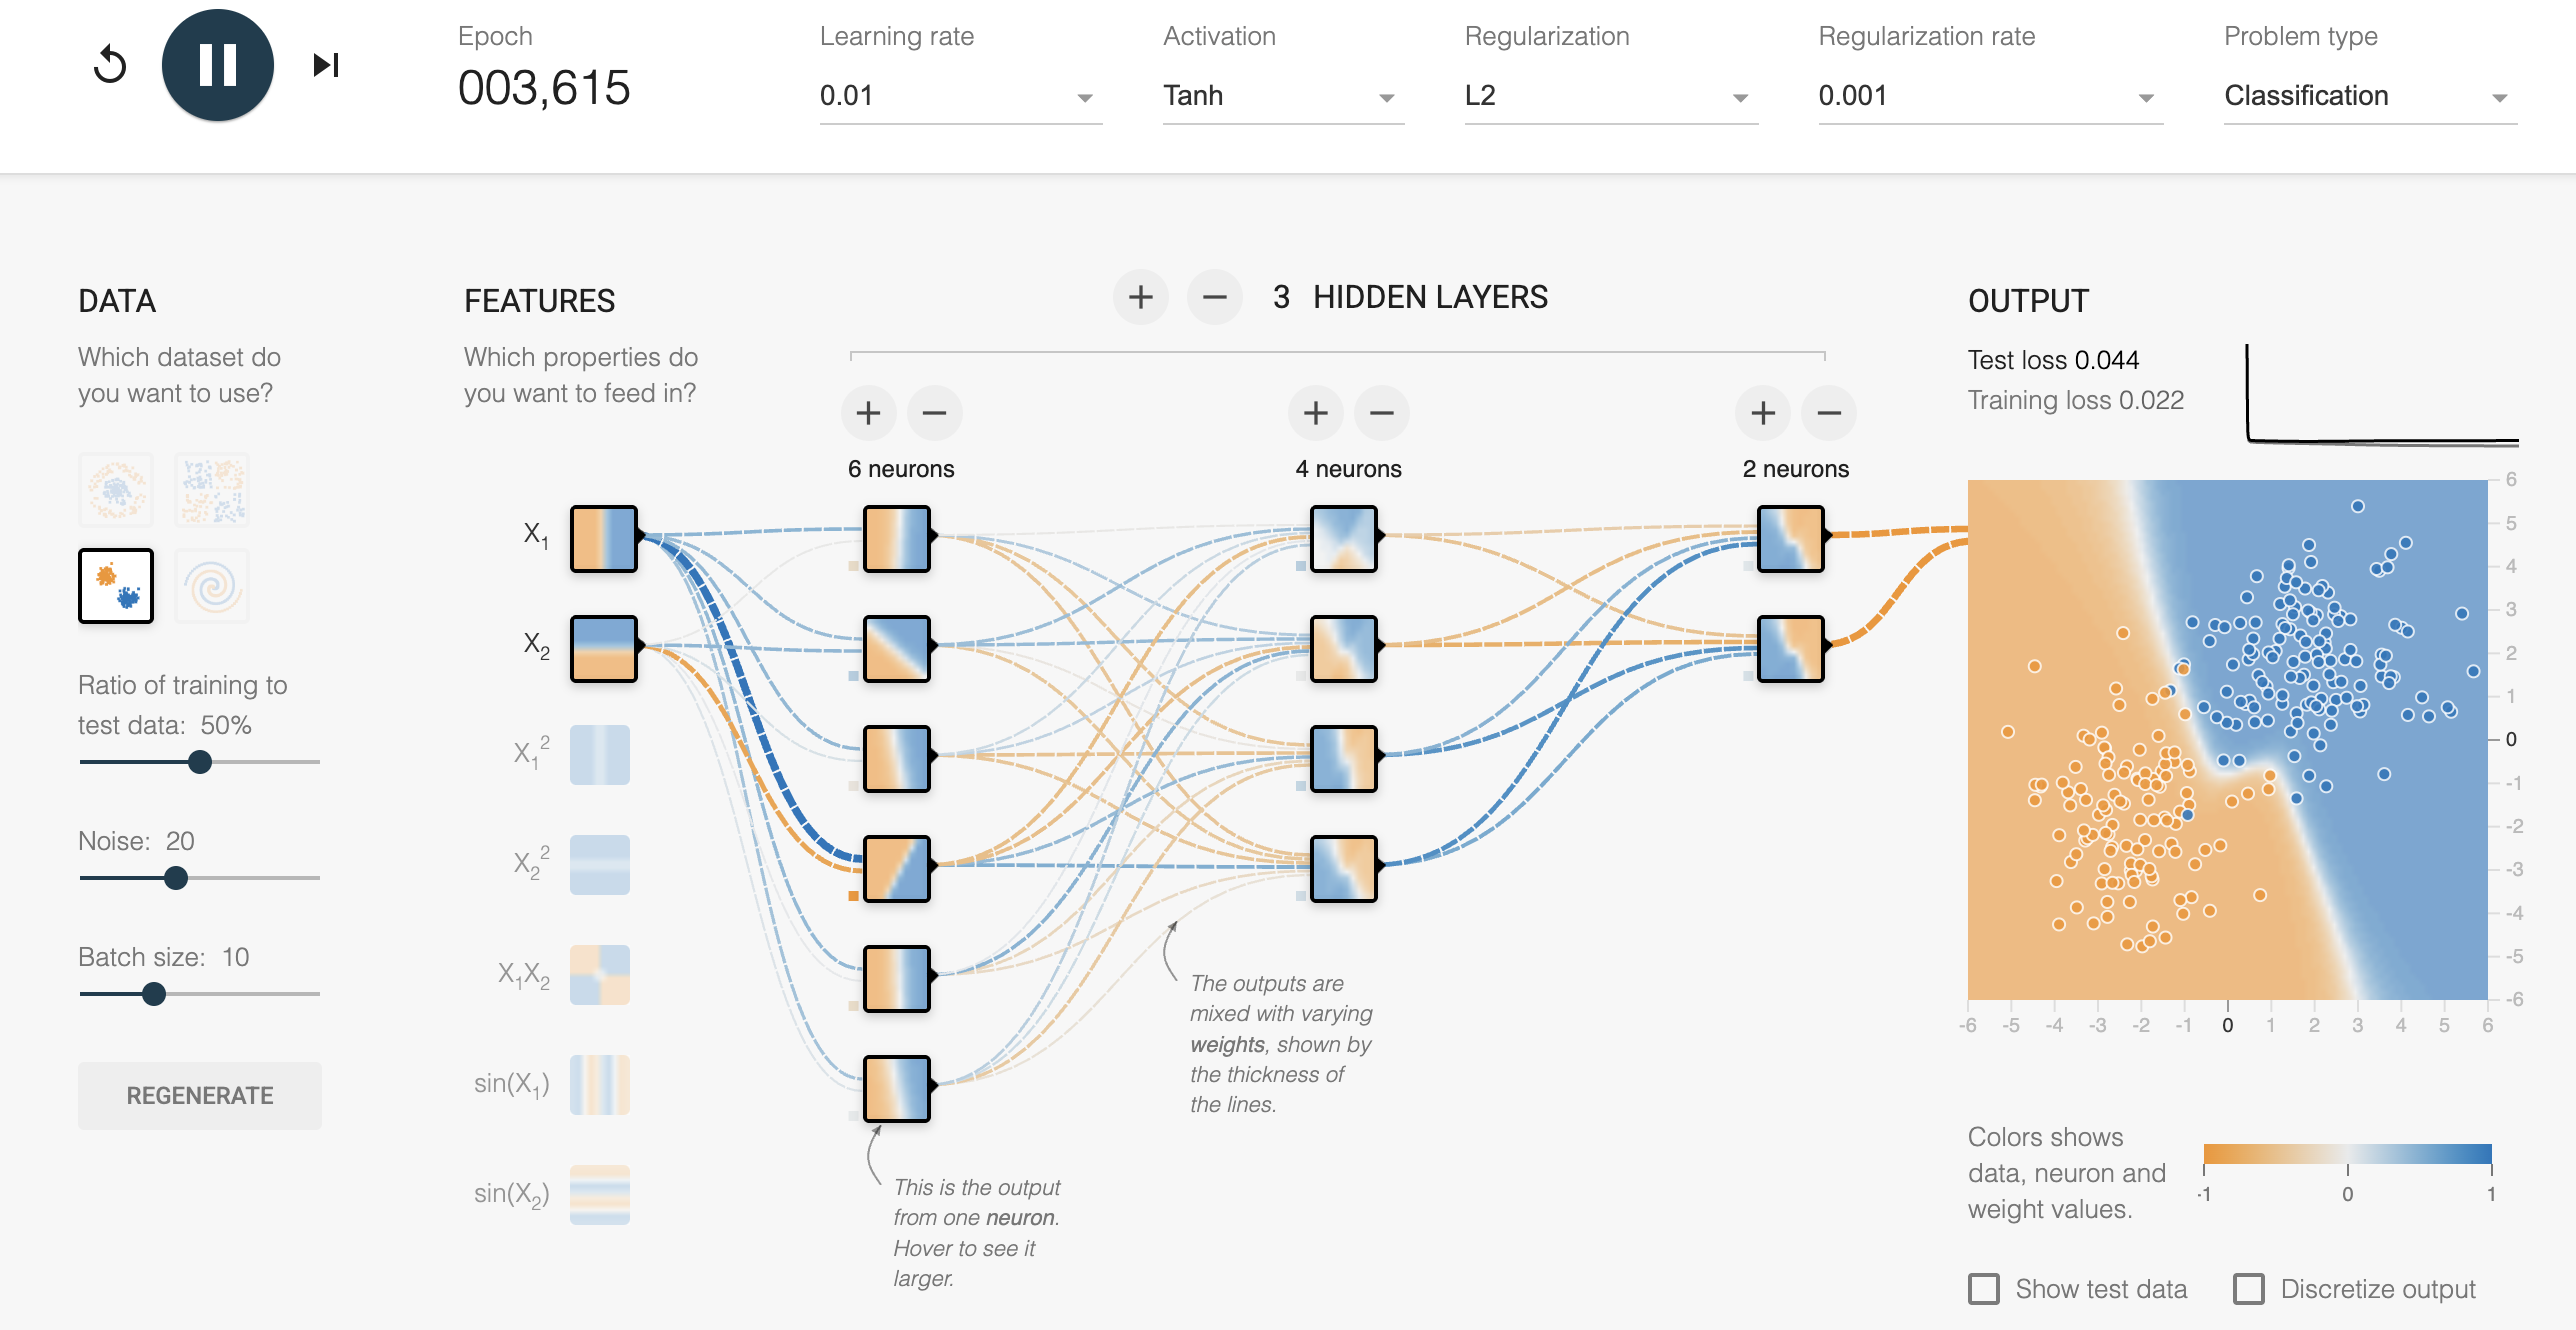

Screenshot for Model C

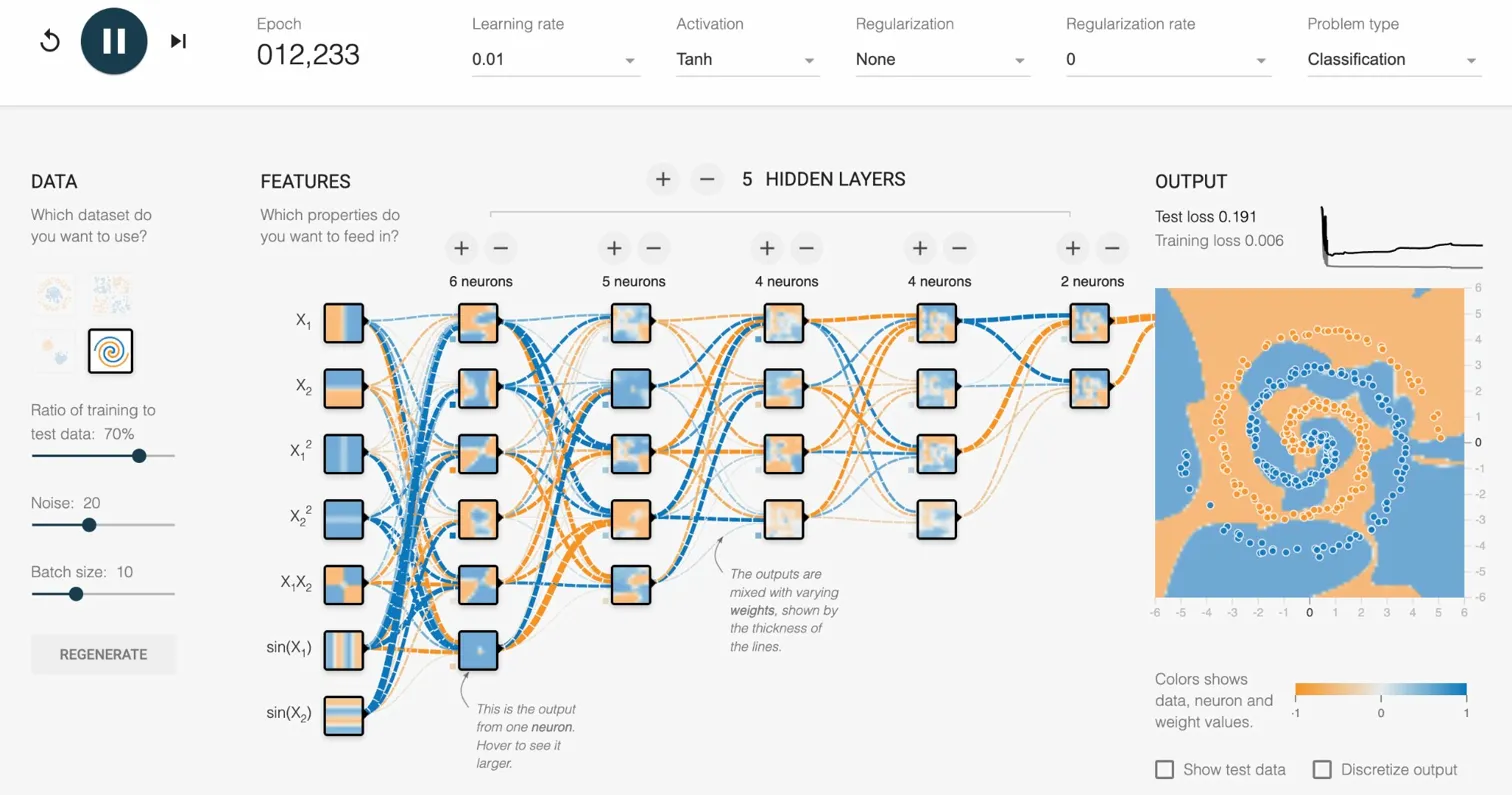

Screenshot for Model D

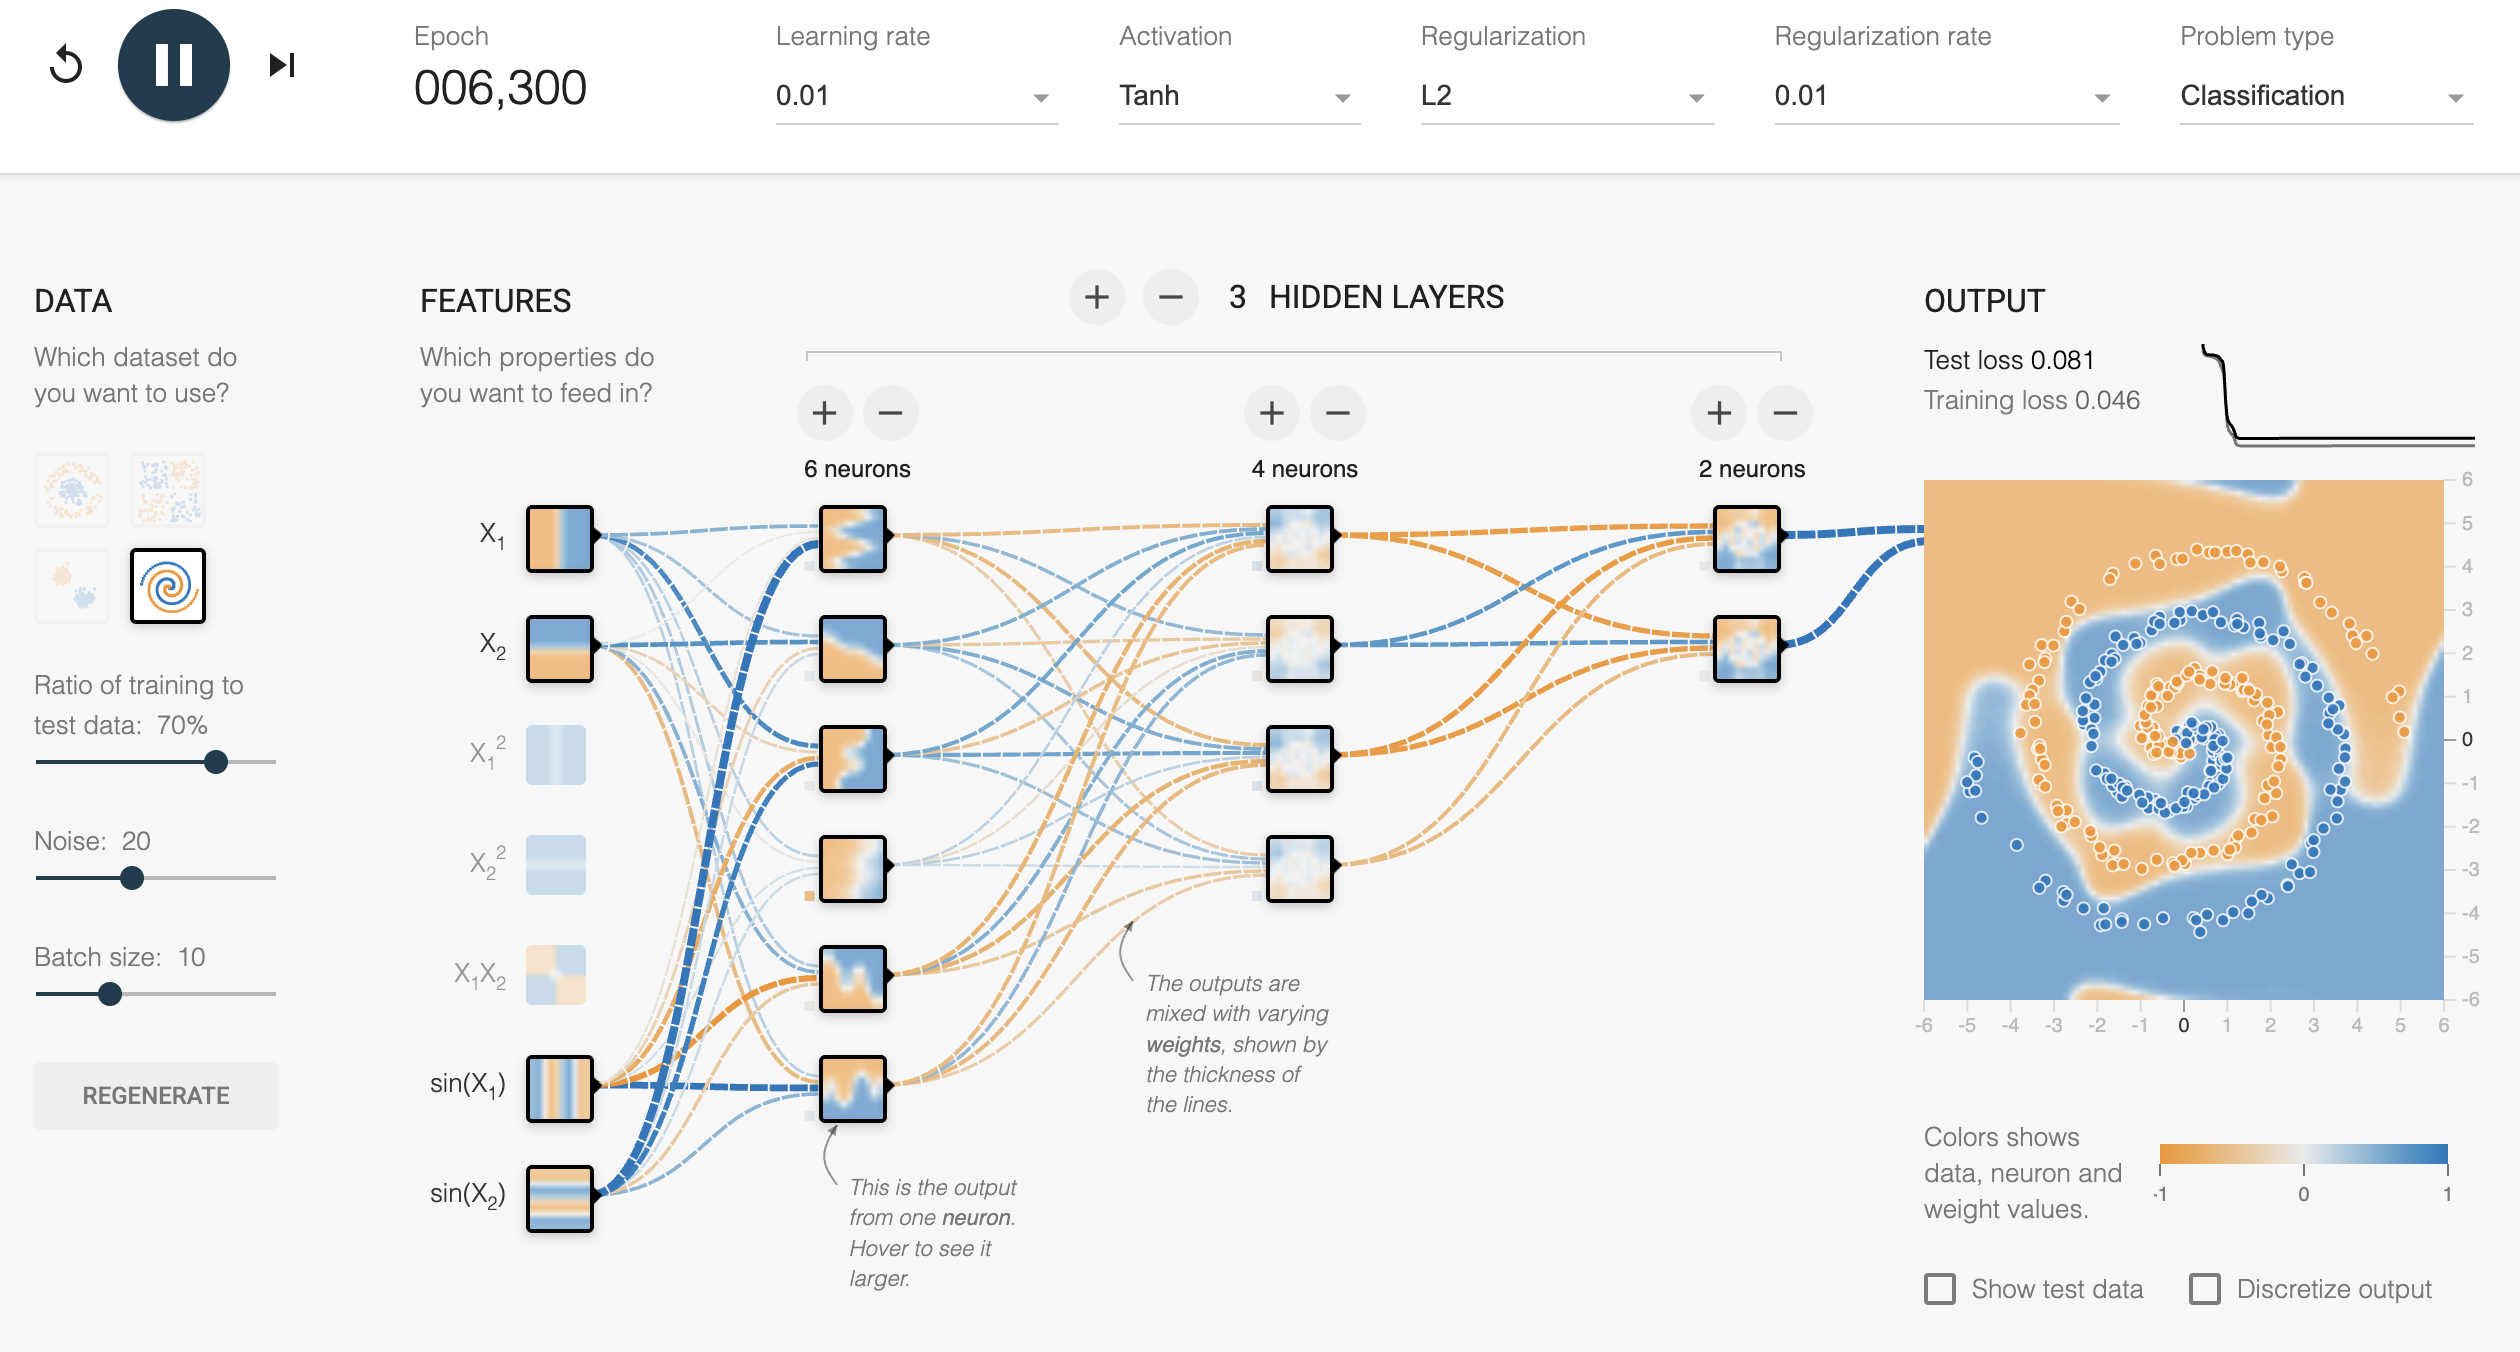

#### 4.2 Discuss your results

Submit a brief write-up analyzing your results. For each model, answer the following questions:

* What specific changes did you make to the features, hidden layers, or number of nodes to transition from an overfit model to a well-fitted model? Why did changing these parameters help?

* Look at the background color map in the final output column. How does the decision boundary of your overfitted model visually differ from your well-fitted model in terms of smoothness, complexity, and how it treats outlier "noisy" dots?

* If applicable: Look at the "Features" column. If you provide the model with complex, non-linear features (like $X_1^2$, $X_2^2$, or $\sin(X_1)$), how does that change the number of hidden layers or neurons required to get a good fit?



**Answer:**

Model A:

-  Trained on dataset 1 (cluster template, 50% training, 20 noise, 10 batch size). Designed with 5 hidden layers (8-6-5-2-2 neurons), all 7 features, learning rate 0.1, Tanh activation, and no regularization. The excessive depth and width gave the model far more parameters than the dataset actually needs, and the absence of regularization allowed it to freely memorize noisy training points. This produced a train loss of 0.004 with test loss of 0.097 (approximately a 24 ratio).

- The boundary is irregular. It detours around individual noisy training points, creating small isolated color islands. The background color map shows sharp transitions and fractured patches rather than a clean separator between the two clusters.

- All 7 features were used including $X_1^2$, $X_2^2$, $X_1X_2$, $sin(X_1)$, $sin(X_1)$. For a nearly linearly separable Gaussian dataset, these non-linear features are unnecessary. Providing these extra features to a 5-layer network gave the model many redundant dimensions to exploit, making it easier to carve complex boundaries around noisy points and leads to overfitting.

Model B:

Trained on dataset 1 (cluster template, 50% training, 20 noise, 10 batch size). Designed with 3 hidden layers (6-4-2 neurons), and trimmed features to only $X_1$, $X_2$, added L2 regularization (rate 0.001), keeping learning rate and activation the same. The reduced capacity limits what the model can memorize, and L2 penalizes large weights, pushing the decision boundary toward smoother, simpler shapes. Together these changes brought train loss to 0.022 and test loss to 0.044 (2 ratio).

The boundary is a smooth curve with a turning points, cleanly dividing the two clusters. Noisy outlier points are ignored, the boundary does not bend toward them. The background color gradient transitions gradually, reflecting stable and confident predictions across the space.

Only $X_1$ and $X_2$ are used.  Since the two clusters are nearly linearly separable, no non-linear transformation is needed. Using only linear features meant the model had no extra dimensions to exploit for overfitting. Using only linear features meant the model had no extra dimensions to exploit for overfitting, and the 3-layer architecture was sufficient to learn the clean boundary.

Model C:

Trained on dataset (spiral template, 70% training set, 20 noise, 10 batch size). Designed with 5 hidden layers (6-5-4-4-2), all 7 features, learning rate 0.01, Tanh activation, and no regularization. The spiral is a hard non-linear problem, so a deep network with all features and no regularization aggressively fits the intricate boundaries around noisy points. A relatively low learning rate (0.01) gave the model enough steps to converge precisely to a memorized solution, producing train loss 0.006 and test loss 0.191 (approximately 32 ratio).

The boundary is in a complex and fragmented spiral shape. It twists tightly around the spiral arms and creates isolated patches of color wherever noisy points appear off the main spiral. The decision boundary looks scratchy around individual training points rather than capturing the spiral structure as a whole.

All 7 features were used. For the spiral, $sin(X_1)$ and $sin(X_2)$ are genuinely informative because the pattern is rotational. However, $X_1^2$, $X_2^2$, and $X_1X_2$ are redundant for this structure and gave the deep 5-layer network extra dimensions to fit noise. The combination of informative and redundant non-linear features in a high-capacity network made overfitting more severe, the model used every available dimension to memorize the noisy spiral boundaries.

Model D:

Trained on dataset (spiral template, 70% training set, 20 noise, 10 batch size). Comparing to model C, model D is reduced to 3 hidden layers (6-4-3) and trimmed features to only $X_1$, $X_2$, $sin(X_1)$, $sin(X_2)$₂. The spiral pattern is fundamentally rotational, so sin features are genuinely informative while polynomial features are redundant noise amplifiers. Fewer features and shallower architecture forced the model to learn the general spiral shape rather than memorize individual points, achieving train loss 0.046 and test loss 0.081 ($\approx$ 1.76 ratio).

The boundary is a relatively smooth, continuous spiral curve that reflects the true underlying pattern. Noisy outlier points are left on the wrong side of the boundary rather than being chased. The color map shows clean, gradually transitioning regions that follow the spiral arms without over-reacting to individual points.

Only $X_1$, $X_2$, $sin(X_1)$, $sin(X_2)$ were used. By keeping the informative non-linear features and removing redundant ones, a shallower 3-layer network was sufficient to capture the spiral structure. The sin features effectively pre-compute the rotational transformation, reducing the depth required — the network doesn't need extra layers to approximate rotation. This shows that well-chosen non-linear features can reduce required architecture complexity while improving generalization.